<a href="https://colab.research.google.com/github/TejasKayarkar03/Machine-Vision-CM45/blob/main/MV_Pr2_CM23045.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

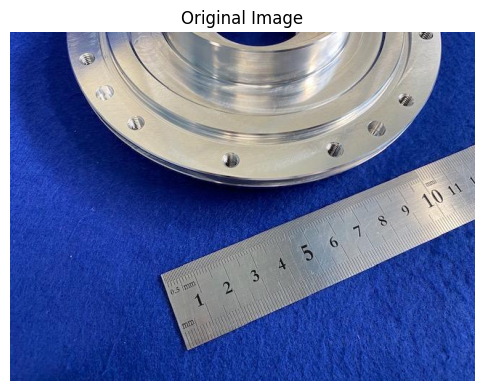

In [ ]:
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
scaled = cv2.resize(image, None, fx=3.5, fy=3.5)

plt.figure(figsize=(6,6))
plt.imshow(scaled)
plt.title("Scaled Image (1.5x)")
plt.axis("off")
plt.show()

NameError: name 'cv2' is not defined

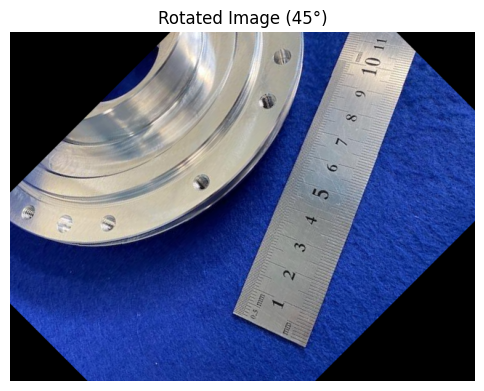

In [ ]:
(h, w) = image.shape[:2]
center = (w//2, h//2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1)

rotated = cv2.warpAffine(image, rotation_matrix, (w, h))

plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.title("Rotated Image (45°)")
plt.axis("off")
plt.show()

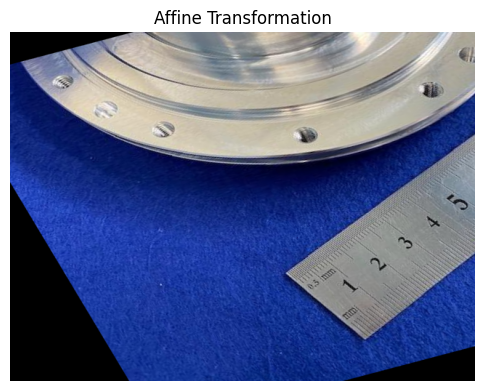

In [ ]:
rows, cols = image.shape[:2]

pts1 = np.float32([[50,50],
                   [200,50],
                   [50,200]])

pts2 = np.float32([[10,100],
                   [200,50],
                   [100,250]])

matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(image, matrix, (cols, rows))

plt.figure(figsize=(6,6))
plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

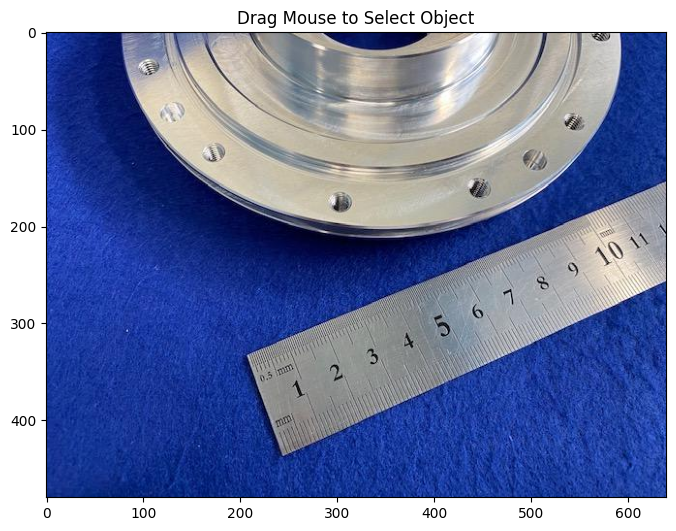

In [ ]:
from matplotlib.widgets import RectangleSelector

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(image)
ax.set_title("Drag Mouse to Select Object")

coords = []

def line_select_callback(eclick, erelease):
    x1, y1 = int(eclick.xdata), int(eclick.ydata)
    x2, y2 = int(erelease.xdata), int(erelease.ydata)

    width = abs(x2-x1)
    height = abs(y2-y1)

    print("Width (pixels):", width)
    print("Height (pixels):", height)

RectangleSelector(
    ax,
    line_select_callback,
    useblit=True,
    button=[1],
    minspanx=5,
    minspany=5,
    interactive=True
)

plt.show()

In [ ]:
pixel_width = 250
pixel_height = 180

pixels_per_cm = 100 / 5

width_cm = pixel_width / pixels_per_cm
height_cm = pixel_height / pixels_per_cm

print("Estimated Width:", round(width_cm,2), "cm")
print("Estimated Height:", round(height_cm,2), "cm")

Estimated Width: 12.5 cm
Estimated Height: 9.0 cm
